In [1]:
import nnsight
import torch
from src.tasks.mix_group_addition import MixRosetteGroupAddition
from src.load_utils import load_gpt, load_task
from src.coverage import copy_rates_over_sequence, reverse_copy_rates_over_sequence, identity_rates_over_sequence, closure_elimination_rates_over_sequence, random_seen_guess_rates_over_sequence, associativity_rates_over_sequence

In [2]:
dirname = '../outputs/mixrosette-facts-10-16-8heads'
gpt = load_gpt(dirname).cuda()
task, task_name = load_task(dirname)
model = nnsight.NNsight(gpt)

number of parameters: 50.42M
iteration: inf
Trained on mixrosette up to order 10 with 16 symbols


#### Empirical Coverage of Training Data

In [ ]:
task = MixRosetteGroupAddition()

batch_size = 1000
num_facts = 200
train_batch = task.sample_batch(batch_size, k_shots=num_facts)

print("Computing Copying")
# Copy Analysis
copying_rate, copying_std, can_copy_tensor = copy_rates_over_sequence(train_batch)
copy_std_errors = copying_std / torch.sqrt(torch.tensor([batch_size]))

print("Computing Commutative Copying")
# Reverse copy analysis (excluding direct copy)
reverse_copy_rate, reverse_copy_stds, can_reverse_copy_tensor = reverse_copy_rates_over_sequence(
    train_batch,
    exclude_masks={'copy': can_copy_tensor}
)

print("Computing Identity")
# Absolute identity analysis - identity solvable (non-copyable) / all cases
identity_non_copy_rates, identity_non_copy_stds, can_identity_tensor = identity_rates_over_sequence(
    train_batch,
    exclude_masks={
        'copy': can_copy_tensor,
        'reverse_copy': can_reverse_copy_tensor
    }
)
identity_non_copy_std_errors = identity_non_copy_stds / torch.sqrt(torch.tensor([batch_size]))

print("Computing Closure")
# Absolute closure+elimination analysis - closure solvable (non-copyable AND non-identity) / all cases
closure_rates, closure_stds, can_closure_tensor = closure_elimination_rates_over_sequence(
    train_batch,
    exclude_masks={
        'copy': can_copy_tensor,
        'reverse_copy': can_reverse_copy_tensor,
        'identity': can_identity_tensor
    }
)
closure_std_errors = closure_stds / torch.sqrt(torch.tensor([batch_size]))

print("Computing Associativity")
# Associativity analysis - associativity solvable (excluding simpler rules) / all cases
assoc_rates, assoc_stds, can_assoc_tensor = associativity_rates_over_sequence(
    train_batch,
    task,
    min_3_facts=False,  # Include both 2-fact and 3-fact associativity
    exclude_masks={
        'copy': can_copy_tensor,
        'reverse_copy': can_reverse_copy_tensor,
        'identity': can_identity_tensor,
        'closure': can_closure_tensor
    }
)
assoc_std_errors = assoc_stds / torch.sqrt(torch.tensor([batch_size]))

# Cumulative explained rates
copy_reverse = copying_rate + reverse_copy_rate
copy_identity_explained = copying_rate + reverse_copy_rate + identity_non_copy_rates
copy_identity_closure_explained = copying_rate + reverse_copy_rate + identity_non_copy_rates + closure_rates
copy_identity_closure_assoc_explained = copying_rate + reverse_copy_rate + identity_non_copy_rates + closure_rates + assoc_rates

Computing Copying
Computing Commutative Copying
Computing Identity
Computing Closure
Computing Associativity


In [4]:
# compute model performance over entire batch
chunk_size = 400
all_correct = []

with torch.no_grad():
    for i in range(0, len(train_batch['inputs']), chunk_size):
        # Get chunk
        end_idx = min(i + chunk_size, len(train_batch['inputs']))
        input_chunk = train_batch['inputs'][i:end_idx].to(model.device)
        target_chunk = train_batch['targets'][i:end_idx]
        
        # Forward pass
        outputs = model(input_chunk)
        if not isinstance(outputs, torch.Tensor):
            outputs = outputs[0]
        predictions = outputs.argmax(2).cpu()
        
        # Compute mask and correctness for this chunk
        mask = input_chunk[0].cpu() == task.predict_token_id
        correct = (predictions[:, mask] == target_chunk[:, mask]).float()
        all_correct.append(correct)
    
    # Concatenate all correctness values and compute mean across batch dimension
    all_correct = torch.cat(all_correct, dim=0)
    accuracy = all_correct.mean(0)  # mean over batch, keeping position dimension

In [12]:
print("Relative Coverage")

curve_names = ["Model Accuracy", "Copying", "Commutative Copying", "Identity Element Recognition", "Closure-Based Cancellation", "Associativity"]

total_training_coverage = 0
for i,d in enumerate([accuracy, copying_rate, reverse_copy_rate, identity_non_copy_rates, closure_rates, assoc_rates]):
    if i !=0:
        total_training_coverage += torch.trapezoid(d)/num_facts
    print(i, curve_names[i] + ":", torch.trapezoid(d)/num_facts)

print("Total Training Coverage:", total_training_coverage)

Relative Coverage
0 Model Accuracy: tensor(0.9238)
1 Copying: tensor(0.6794)
2 Commutative Copying: tensor(0.1205)
3 Identity Element Recognition: tensor(0.0415)
4 Closure-Based Cancellation: tensor(0.0266)
5 Associativity: tensor(0.0362)
Total Training Coverage: tensor(0.9042)


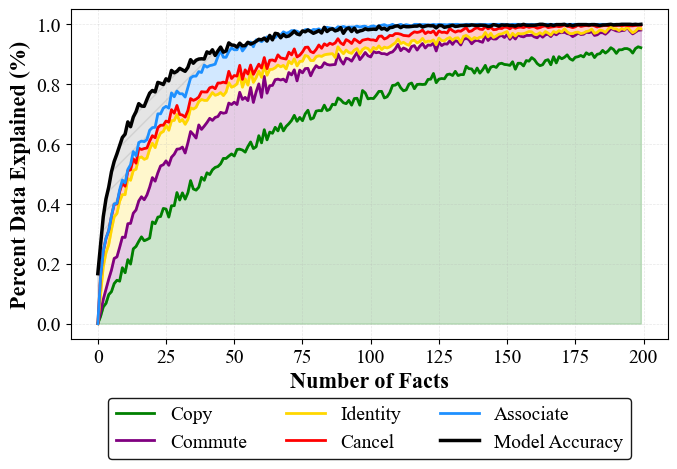

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set the font to Times New Roman with larger sizes for ICLR
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # For math text consistency
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.labelsize'] = 16  # Axis labels
plt.rcParams['axes.titlesize'] = 18  # Title
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['legend.fontsize'] = 14  # Legend
plt.rcParams['figure.titlesize'] = 18  # Figure title

# Create the figure with appropriate size for conference papers
fig, ax = plt.subplots(figsize=(7, 5))  # Adjust figure size for better proportions

x = np.arange(len(accuracy))

# Fill areas from top to bottom
plt.fill_between(x, accuracy, copy_identity_closure_assoc_explained, 
                 color='gray', alpha=0.2, hatch='//', zorder=1, where=(accuracy > copy_identity_closure_assoc_explained))
plt.fill_between(x, copy_identity_closure_assoc_explained, copy_identity_closure_explained, 
                 color='dodgerblue', alpha=0.2, zorder=1)
plt.fill_between(x, copy_identity_closure_explained, copy_identity_explained, 
                 color='red', alpha=0.2, zorder=1)
plt.fill_between(x, copy_identity_explained, copy_reverse, 
                 color='gold', alpha=0.2, zorder=1)
plt.fill_between(x, copy_reverse, copying_rate, 
                 color='purple', alpha=0.2, zorder=1)
plt.fill_between(x, copying_rate, 0, 
                 color='green', alpha=0.2, zorder=1)

# Plot lines with thicker linewidth for better visibility and updated labels
plt.plot(x, copying_rate, label="Copy", zorder=2, 
         color='green', linewidth=2)
plt.plot(x, copy_reverse, color='purple', 
         label='Commute', linewidth=2)
plt.plot(x, copy_identity_explained, label="Identity", 
         zorder=2, color='gold', linewidth=2)
plt.plot(x, copy_identity_closure_explained, color='red', 
         label='Cancel', zorder=2, linewidth=2)
plt.plot(x, copy_identity_closure_assoc_explained, color='dodgerblue', 
         label='Associate', zorder=2, linewidth=2)
plt.plot(x, accuracy, color='black', 
         label="Model Accuracy", zorder=2, linewidth=2.5)  # Slightly thicker for emphasis

# Labels with larger fonts and bold
plt.xlabel("Number of Facts", fontsize=16, fontweight='bold')
plt.ylabel("Percent Data Explained (%)", fontsize=16, fontweight='bold')

# Ensure tick labels are properly sized
ax.tick_params(axis='both', which='major', labelsize=14)

# Legend along the bottom - horizontal layout
plt.legend(frameon=True, fancybox=True, shadow=False, 
          framealpha=0.9, edgecolor='black', fontsize=14,
          loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=3)  # Using 3 columns to fit 5 items nicely

# Grid for better readability (optional, common in conference papers)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Tight layout to prevent label cutoff
plt.tight_layout()

# Save with high DPI for publication quality
# plt.savefig('empirical_coverage_train.pdf', bbox_inches='tight', dpi=300)

plt.show()

In [ ]:
## Save Results

# torch.save({'copy': copying_rate, 'commute': reverse_copy_rate, 
# 'identity': identity_non_copy_rates, 'cancel': closure_rates, 
# 'associate': assoc_rates, 'random':random_guess_rates, 'model_accuracy':accuracy}, 'train_coverage_results.pt')
# # torch.load('train_coverage_results.pt')

##### Held-out Coverage

In [ ]:
from tqdm import tqdm
import torch

# Storage for results
all_identity_rates = []
all_closure_rates = []
all_random_guess_rates = []
all_assoc_rates = []

# Run the loop
for k in tqdm(range(1, 201), desc="Analyzing positions"):
    # Generate batch with holdout at position k
    batch = task.sample_batch(1000, k, hold_out=True, commute_out=True)
    
    # Identity analysis (no exclusions for holdout)
    identity_rate, _, can_identity_tensor = identity_rates_over_sequence(
        batch,
        exclude_masks=None
    )
    # Closure analysis (excluding identity)
    closure_rate, _, can_closure_tensor = closure_elimination_rates_over_sequence(
        batch,
        exclude_masks={'identity': can_identity_tensor}
    )

    # print("Computing Associativity")
    # Associativity analysis - associativity solvable (excluding simpler rules) / all cases
    assoc_rates, assoc_stds, can_assoc_tensor = associativity_rates_over_sequence(
        batch,
        task,
        min_3_facts=False,  # Include both 2-fact and 3-fact associativity
        exclude_masks={
            'identity': can_identity_tensor,
            'closure': can_closure_tensor
        }
    )   

    # Random guess analysis (excluding identity and closure)
    random_guess_rates, _, can_random_guess_tensor = random_seen_guess_rates_over_sequence(
        batch,
        exclude_masks={
            'identity': can_identity_tensor,
            'closure': can_closure_tensor,
            'associate': can_assoc_tensor
        }
    )
    # Store the rate at position k (the last position which is the held-out fact)
    all_identity_rates.append(identity_rate[-1].item())
    all_closure_rates.append(closure_rate[-1].item())
    all_assoc_rates.append(assoc_rates[-1].item())
    all_random_guess_rates.append(random_guess_rates[-1].item())

# Convert to tensors
all_identity_rates = torch.tensor(all_identity_rates)
all_closure_rates = torch.tensor(all_closure_rates)
all_assoc_rates = torch.tensor(all_assoc_rates)
all_random_guess_rates = torch.tensor(all_random_guess_rates)

# Calculate combined rates
identity_explained = all_identity_rates
identity_closure_explained = all_identity_rates + all_closure_rates
idendity_closure_assoc_explained = all_identity_rates + all_closure_rates + all_assoc_rates
identity_closure_assoc_random_guess_explained = all_identity_rates + all_closure_rates + all_assoc_rates + all_random_guess_rates

Analyzing positions: 100%|██████████| 200/200 [4:40:33<00:00, 84.17s/it]   


In [ ]:
def held_out_accuracy(model, task, chunk_size=350, **kwargs):
    device = next(model.parameters()).device
    accuracies = []
    
    for shots in tqdm(range(1, 201)):
        with torch.no_grad():
            batch = task.sample_batch(k_shots=shots, **kwargs)
            
            # Process batch in chunks
            all_correct = []
            for i in range(0, len(batch['inputs']), chunk_size):
                end_idx = min(i + chunk_size, len(batch['inputs']))
                input_chunk = batch['inputs'][i:end_idx].to(device)
                target_chunk = batch['targets'][i:end_idx]
                
                # Forward pass
                outputs = model(input_chunk)
                if not isinstance(outputs, torch.Tensor):
                    outputs = outputs[0]
                predictions = outputs.argmax(2).cpu()
                
                # Compute correctness on final position for this chunk
                correct = (predictions[:, -1] == target_chunk[:, -1]).float()
                all_correct.append(correct)
            
            # Concatenate all correctness values and compute mean
            all_correct = torch.cat(all_correct, dim=0)
            accuracy = all_correct.mean().item()
            
        accuracies.append((shots, accuracy))
    
    return zip(*accuracies)

acc_scores = list(held_out_accuracy(model, task, chunk_size=350, batch_size=1000, hold_out=True, commute_out=True))

100%|██████████| 200/200 [04:28<00:00,  1.34s/it]


In [ ]:
### Save Results

# torch.save({'identity': all_identity_rates, 'cancel': all_closure_rates, 
#             'associate': all_assoc_rates, 'random':all_random_guess_rates, 
#             'model_accuracy':acc_scores[1]}, 
#             'holdout_coverage_results.pt')

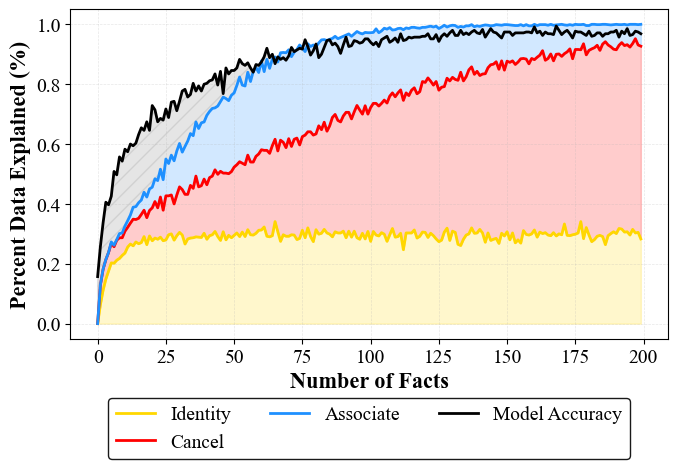

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set the font to Times New Roman with larger sizes for ICLR
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # For math text consistency
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.labelsize'] = 16  # Axis labels
plt.rcParams['axes.titlesize'] = 18  # Title
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['legend.fontsize'] = 14  # Legend
plt.rcParams['figure.titlesize'] = 18  # Figure title

# Create the figure with appropriate size for conference papers
fig, ax = plt.subplots(figsize=(7, 5))  # Adjust figure size for better proportions

x = np.arange(len(identity_explained))

# Fill between plots
plt.fill_between(x, acc_scores[1], idendity_closure_assoc_explained, where=(torch.tensor(acc_scores[1]) > idendity_closure_assoc_explained),
                 color='gray', alpha=0.2, hatch='//', zorder=1)
# plt.fill_between(x, identity_closure_assoc_random_guess_explained, idendity_closure_assoc_explained, 
                #  color='orange', alpha=0.2, zorder=1)
plt.fill_between(x, idendity_closure_assoc_explained, identity_closure_explained, 
                 color='dodgerblue', alpha=0.2, zorder=1)
plt.fill_between(x, identity_closure_explained, identity_explained, 
                 color='red', alpha=0.2, zorder=1)
plt.fill_between(x, identity_explained, 0, 
                 color='gold', alpha=0.2, zorder=1)

# Line plots with slightly thicker lines for better visibility
plt.plot(x, identity_explained, label="Identity", zorder=2, color='gold', linewidth=2)
plt.plot(x, identity_closure_explained, color='red', label='Cancel', zorder=2, linewidth=2)
plt.plot(x, idendity_closure_assoc_explained, color='dodgerblue', label='Associate', zorder=2, linewidth=2)
# plt.plot(x, identity_closure_assoc_random_guess_explained, color='orange', label="Random Guess", zorder=2, linewidth=2)
plt.plot(x, acc_scores[1], color='black', label="Model Accuracy", zorder=2, linewidth=2)

# Labels with larger fonts
plt.xlabel("Number of Facts", fontsize=16, fontweight='bold')
plt.ylabel("Percent Data Explained (%)", fontsize=16, fontweight='bold')

# Ensure tick labels are properly sized
ax.tick_params(axis='both', which='major', labelsize=14)

# Legend along the bottom
plt.legend(frameon=True, fancybox=True, shadow=False, 
          framealpha=0.9, edgecolor='black', fontsize=14,
          loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=3)  # Adjust ncol based on number of items

# Grid for better readability (optional, common in conference papers)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
# Save with high DPI for publication quality
# plt.savefig('empirical_coverage_holdout.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
print("Relative Coverage")

curve_names = ["Model Accuracy", "Identity Element Recognition", "Closure-Based Cancellation", "Associativity"]

total_holdout_coverage = 0
for i,d in enumerate([torch.tensor(acc_scores[1]), all_identity_rates, all_closure_rates, all_assoc_rates]):
    if i !=0:
        total_holdout_coverage += torch.trapezoid(d)/num_facts
    print(i, curve_names[i] + ":", torch.trapezoid(d)/num_facts)

print("Total Holdout Coverage:", total_holdout_coverage)

Relative Coverage
0 Model Accuracy: tensor(0.8734)
1 Identity Element Recognition: tensor(0.2867)
2 Closure-Based Cancellation: tensor(0.3909)
3 Associativity: tensor(0.1685)
Total Holdout Coverage: tensor(0.8461)
